<a href="https://colab.research.google.com/github/FebrianArkaSamudra/PCVK_2025_FebrianArkaSamudra/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

Transformasi Linier Brightness

Mengubah tingkat kecerahan citra
Masukkan nilai kecerahan50


/tmp/ipython-input-2077911909.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


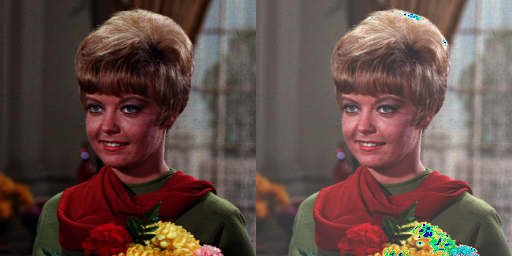

In [62]:
print('Mengubah tingkat kecerahan citra')
print('================================')

try:
  brightness = int(input('Masukkan nilai kecerahan'))
except ValueError:
  print('Nilai harus berupa angka')

original = cv.imread ('/content/drive/MyDrive/PCVK/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# D1 PRACTICAL ASSIGMENT



1.   Implement image inversion on Google Collaboratory using the formulas found in the Theory Review section, resulting in the following output:




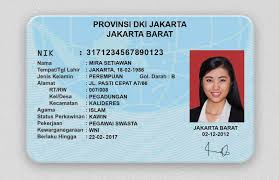

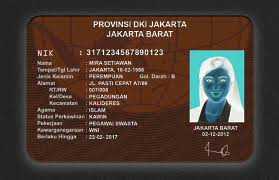

In [63]:
# ✅ Import necessary libraries first!
import cv2
from google.colab.patches import cv2_imshow

# ✅ Load image
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/KTP.jpeg')  # Make sure path is correct

# ✅ Invert image
inverted = 255 - img

# ✅ Show original and inverted image
cv2_imshow(img)
cv2_imshow(inverted)


2. Implement the contrast transformation in Google Collaboratory using the formula found in the Theory Review section for contrast, resulting in the following output:

Adjusting Image Contrast and Brightness
---------------------------------------
Enter brightness value [-255 to 255]: 50
Enter contrast value [1.0 to 3.0]: 2


/tmp/ipython-input-169563122.py:29: RuntimeWarning: overflow encountered in scalar add
  temp = original[y, x, c] + beta        # Apply brightness


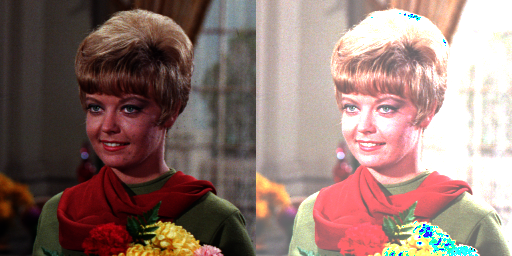

In [64]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print("Adjusting Image Contrast and Brightness")
print("---------------------------------------")

# Get user input for brightness (beta) and contrast (alpha)
try:
    beta = int(input("Enter brightness value [-255 to 255]: "))
    alpha = float(input("Enter contrast value [1.0 to 3.0]: "))
except ValueError:
    print("Error: Invalid input")
    exit()

# Load the image
original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
if original is None:
    print("Image not found. Please check the file path.")
    exit()

# Prepare empty output image with same shape and type
result = np.zeros(original.shape, original.dtype)

# Loop over every pixel and channel to apply contrast and brightness adjustment
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            temp = original[y, x, c] + beta        # Apply brightness
            result[y, x, c] = np.clip(alpha * temp, 0, 255)  # Apply contrast with clamping

# Concatenate original and result images side by side
final_frame = cv.hconcat((original, result))

# Display the result
cv2_imshow(final_frame)


3. Implement the logarithmic brightness transformation in Google Collaboratory using the formula found in the Theory Review section for log transformation, resulting in the following output:

Logarithmic Brightness Transformation
----------------------------------
Enter brightness constant (e.g., 20): 40


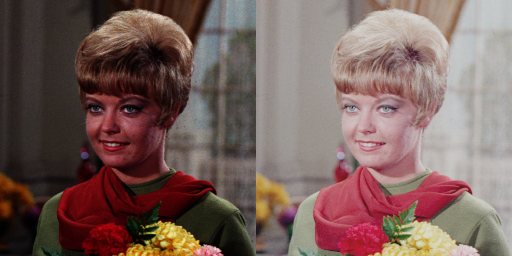

In [65]:
print("Logarithmic Brightness Transformation")
print("----------------------------------")

# Get brightness constant from user input
try:
    c = float(input("Enter brightness constant (e.g., 20): "))
except ValueError:
    print("Invalid input. Using default value c = 1.0")
    c = 1.0

# Load the original image
original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

# Check if image loaded successfully
if original is None:
    print("Image not found. Please check the file path or name.")
else:
    # Convert image to float for log transformation, apply log formula, then convert back to uint8
    log_img = (c * np.log(1 + original.astype(np.float32))).astype(np.uint8)

    # Concatenate original and transformed image for comparison
    final = cv.hconcat([original, log_img])

    # Display the result
    cv2_imshow(final)


4. Implement the grayscale transformation using the averaging, lightness, and luminance methods on Google Collaboratory using the formulas found in the Theory Review section, resulting in the following output:

Averaging

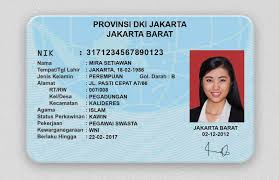

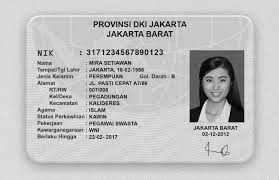

In [66]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/KTP.jpeg')

# Averaging grayscale
gray_avg = np.mean(img, axis=2).astype(np.uint8)

# Show original and grayscale image
cv2_imshow(img)
cv2_imshow(gray_avg)


Lightness

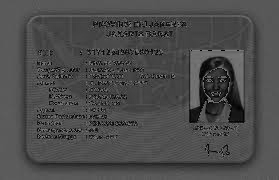

In [67]:
# ✅ Lightness = (max(R, G, B) + min(R, G, B)) / 2
min_val = np.min(img, axis=2)
max_val = np.max(img, axis=2)
gray_lightness = ((min_val + max_val) / 2).astype(np.uint8)

cv2_imshow(gray_lightness)


Luminance

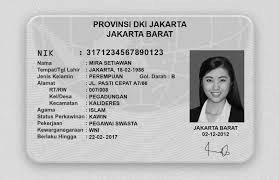

In [68]:
# ✅ Luminance = 0.299 * R + 0.587 * G + 0.114 * B
gray_luminance = (0.299 * img[:, :, 2] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 0]).astype(np.uint8)

cv2_imshow(gray_luminance)


5. Display certain colors in an image and convert other colors to grayscale. For example, display blue in the input image and convert other non-blue parts to grayscale,as in the following example:


=== TASK 5: SELECTIVE COLOR DISPLAY (BLUE) ===


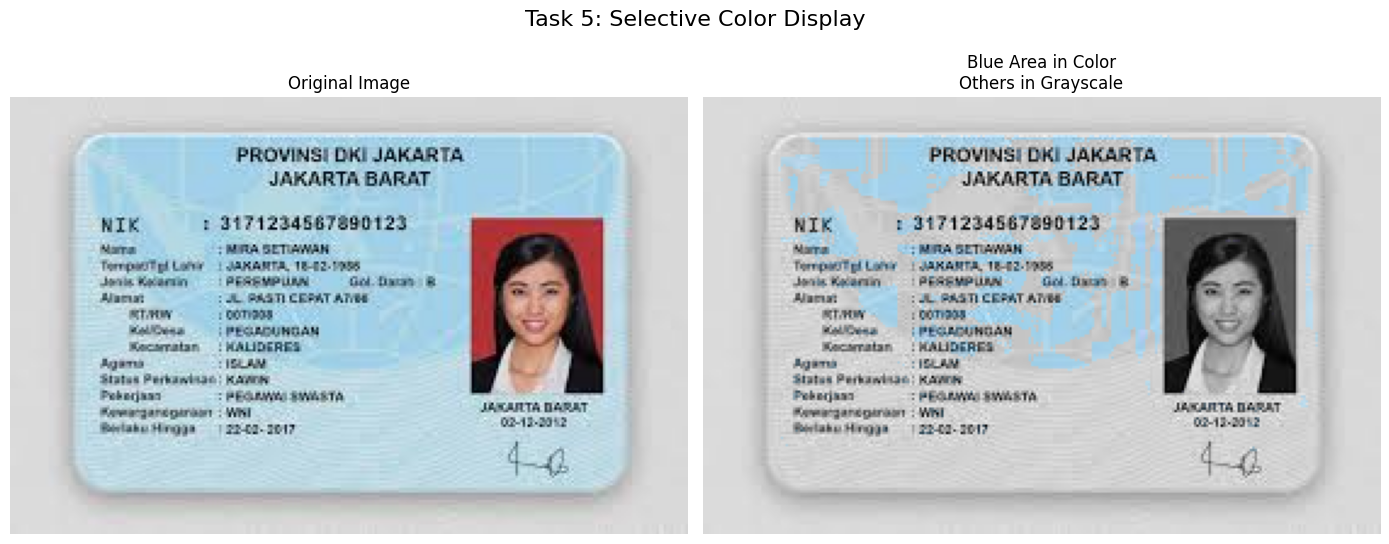

Task 5: Successfully displayed color 'blue' with others in grayscale.


In [69]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def task5_selective_color_display(target_color='blue'):
    """
    Task 5: Selective Color Display
    Display only the selected color (e.g., blue) while converting all other regions to grayscale.
    """
    print(f"=== TASK 5: SELECTIVE COLOR DISPLAY ({target_color.upper()}) ===")

    # Load the input image
    img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTP.jpeg')
    if img is None:
        print("Image not found. Please check the file path.")
        return None, None, None

    # Convert from BGR to RGB (for display) and to HSV (for color masking)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

    # Define HSV color ranges for blue, red, and green
    color_ranges = {
        'blue': {
            'lower': np.array([100, 50, 50]),
            'upper': np.array([130, 255, 255])
        },
        'red': {
            'lower': np.array([0, 50, 50]),
            'upper': np.array([10, 255, 255])
        },
        'green': {
            'lower': np.array([40, 50, 50]),
            'upper': np.array([80, 255, 255])
        }
    }

    # Create a binary mask for the selected color
    if target_color in color_ranges:
        mask = cv.inRange(img_hsv, color_ranges[target_color]['lower'], color_ranges[target_color]['upper'])
    else:
        print(f"Color '{target_color}' is not recognized. Defaulting to blue.")
        mask = cv.inRange(img_hsv, color_ranges['blue']['lower'], color_ranges['blue']['upper'])

    # Convert the original image to grayscale and then back to 3-channel
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_3channel = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

    # Combine grayscale and color: only keep selected color, rest become grayscale
    selective_img = gray_3channel.copy()
    selective_img[mask > 0] = img_rgb[mask > 0]

    # Display the original and selectively colored images
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(selective_img)
    plt.title(f'{target_color.capitalize()} Area in Color\nOthers in Grayscale')
    plt.axis('off')

    plt.suptitle('Task 5: Selective Color Display', fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Task 5: Successfully displayed color '{target_color}' with others in grayscale.")
    return img_rgb, selective_img, mask

# Run Task 5 for blue color
original, selective_result, mask = task5_selective_color_display('blue')


# D2 Arithmetic and Logical Operations



1.Make Gamma Correction According to the following instructions

=== TASK 1: GAMMA CORRECTION ===


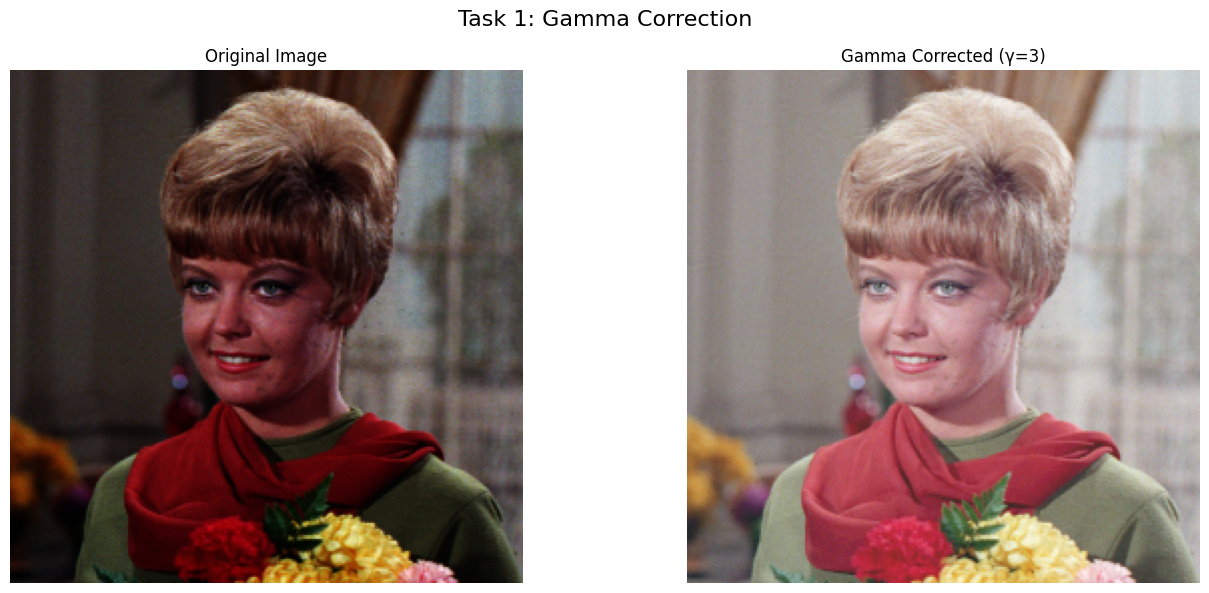

Task 1: Gamma correction completed.


In [70]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def task1_gamma_correction(gamma_value=3):
    """
    Task 1: Gamma Correction
    Adjusts the brightness of an image using gamma transformation.
    Formula: output = (input / 255)^(1/gamma) * 255
    """

    print("=== TASK 1: GAMMA CORRECTION ===")

    # Load the image
    img = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
    if img is None:
        print("Image not found.")
        return None, None

    # Convert BGR (OpenCV default) to RGB (for correct display in matplotlib)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Create a lookup table for gamma correction
    invGamma = 1.0 / gamma_value
    table = np.array([
        ((i / 255.0) ** invGamma) * 255 for i in np.arange(256)
    ]).astype("uint8")

    # Apply gamma correction using the lookup table
    gamma_corrected = cv.LUT(img_rgb, table)

    # Display the original and gamma-corrected images side by side
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gamma_corrected)
    plt.title(f"Gamma Corrected (γ={gamma_value})")
    plt.axis("off")

    plt.suptitle("Task 1: Gamma Correction", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("Task 1: Gamma correction completed.")
    return img_rgb, gamma_corrected

# Execute the function with gamma = 3
original, corrected = task1_gamma_correction(gamma_value=3)


2. Create Image Depth Simulation

=== TASK 2: IMAGE DEPTH SIMULATION (bit-depth = 2) ===


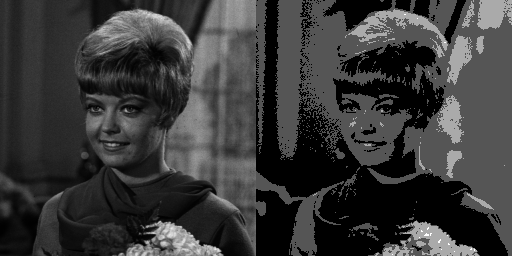

Task 2 completed. Image displayed with bit-depth: 2


In [71]:
def task2_image_depth_simulation(bit_depth=2):
    """
    Task 2: Image Depth Simulation (Quantization)
    Simulates a reduction in image bit-depth by quantizing grayscale pixel values.
    """

    print(f"=== TASK 2: IMAGE DEPTH SIMULATION (bit-depth = {bit_depth}) ===")

    # Load grayscale image
    original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff', cv.IMREAD_GRAYSCALE)
    if original is None:
        print("Image not found.")
        return

    # Calculate the number of intensity levels for the given bit depth
    levels = 2 ** bit_depth
    scale = 255 / (levels - 1)

    # Apply quantization: reduce precision to simulate lower bit-depth
    quantized = np.uint8(np.round(original / scale) * scale)

    # Concatenate original and quantized images side by side
    combined = cv.hconcat([original, quantized])

    # Display the result
    cv2_imshow(combined)

    print(f"Task 2 completed. Image displayed with bit-depth: {bit_depth}")

# Run simulation for bit depth = 2 (example value)
task2_image_depth_simulation(bit_depth=2)


3. Create an Average Denoising module

=== TASK 3: AVERAGE DENOISING MODULE ===
Total noisy images found: 100


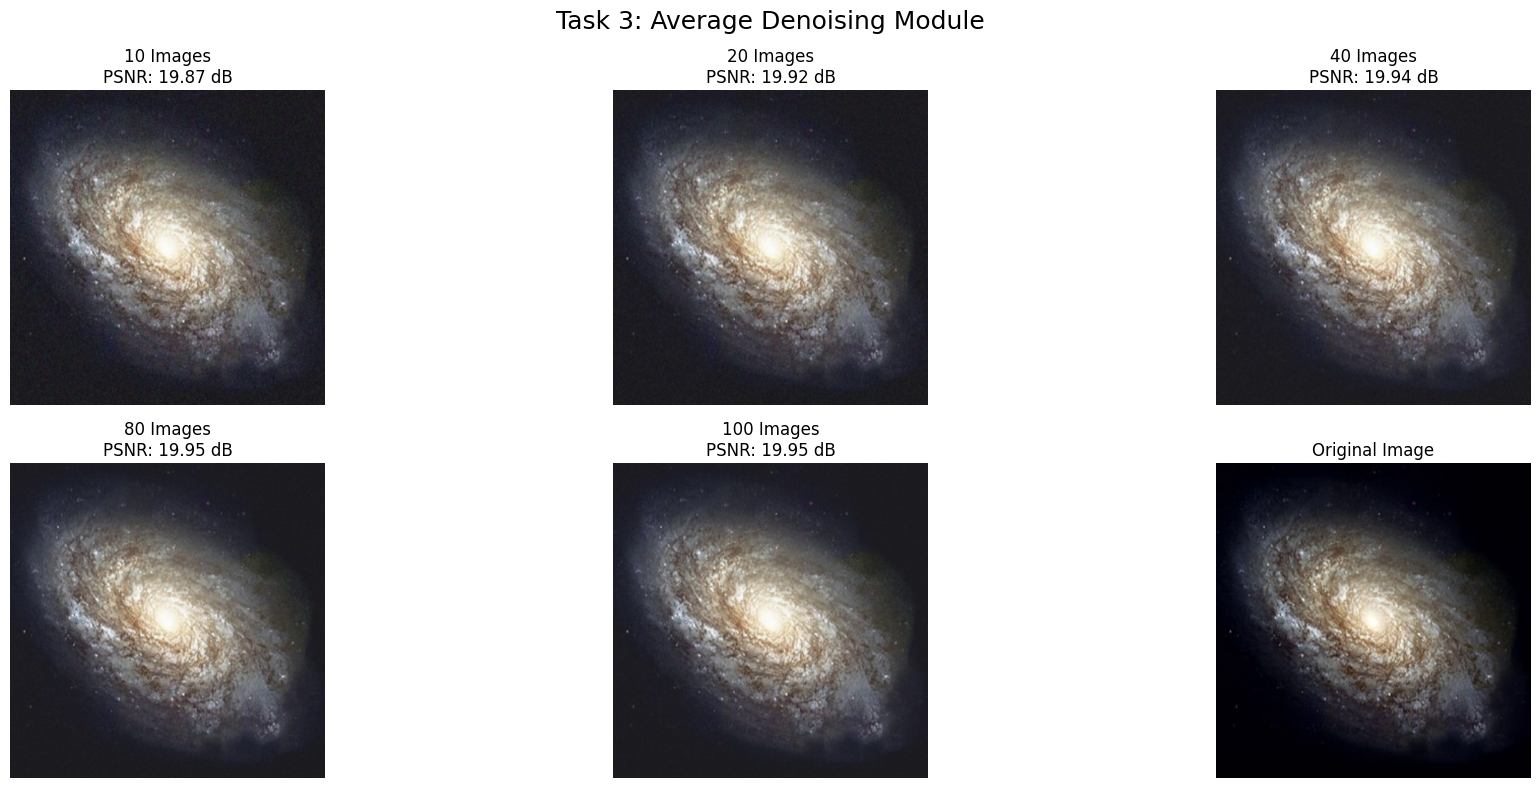


--- PSNR RESULTS ---
10 Images : 19.87 dB
20 Images : 19.92 dB
40 Images : 19.94 dB
80 Images : 19.95 dB
100 Images : 19.95 dB


In [72]:
def task3_average_denoising_all():
    """
    TASK 3: AVERAGE DENOISING MODULE
    Removes noise from an image by averaging multiple noisy versions of it.
    Variations: 10, 20, 40, 80, 100 noisy images
    """

    print("=== TASK 3: AVERAGE DENOISING MODULE ===")

    # Load the ground truth (original image)
    original = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
    original = cv.resize(original, (512, 512))

    # Load all noisy images from the folder
    noisy_paths = sorted(glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'))
    total_images = len(noisy_paths)
    print(f"Total noisy images found: {total_images}")

    # Check if there are at least 100 images
    if total_images < 100:
        print("Not enough noisy images (minimum 100 required). Please check the folder.")
        return

    # Read and resize all noisy images
    noisy_imgs = [cv.resize(cv.imread(p), (512, 512)) for p in noisy_paths]

    # Different numbers of images to average
    image_counts = [10, 20, 40, 80, 100]
    psnr_results = []

    # Prepare to display the denoised results
    plt.figure(figsize=(20, 8))

    for idx, count in enumerate(image_counts):
        # Initialize a zero array to accumulate pixel values
        avg_img = np.zeros_like(noisy_imgs[0], dtype=np.float32)

        # Sum the first 'count' noisy images
        for i in range(count):
            avg_img += noisy_imgs[i].astype(np.float32)

        # Divide by the number of images to compute the average
        avg_img /= count
        avg_img = np.uint8(avg_img)

        # Compute PSNR compared to the original image
        psnr = cv.PSNR(original, avg_img)
        psnr_results.append((count, psnr))

        # Display the denoised image
        plt.subplot(2, 3, idx + 1)
        plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
        plt.title(f"{count} Images\nPSNR: {psnr:.2f} dB")
        plt.axis("off")

    # Display the original image for reference
    plt.subplot(2, 3, 6)
    plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    # Finalize the plot
    plt.suptitle("Task 3: Average Denoising Module", fontsize=18)
    plt.tight_layout()
    plt.show()

    # Print the PSNR results in the console
    print("\n--- PSNR RESULTS ---")
    for count, psnr in psnr_results:
        print(f"{count} Images : {psnr:.2f} dB")

# Run the task
task3_average_denoising_all()


4. Create image masking

=== TASK 4: LOGICAL OPERATIONS WITH MASKING (3x2 Layout) ===


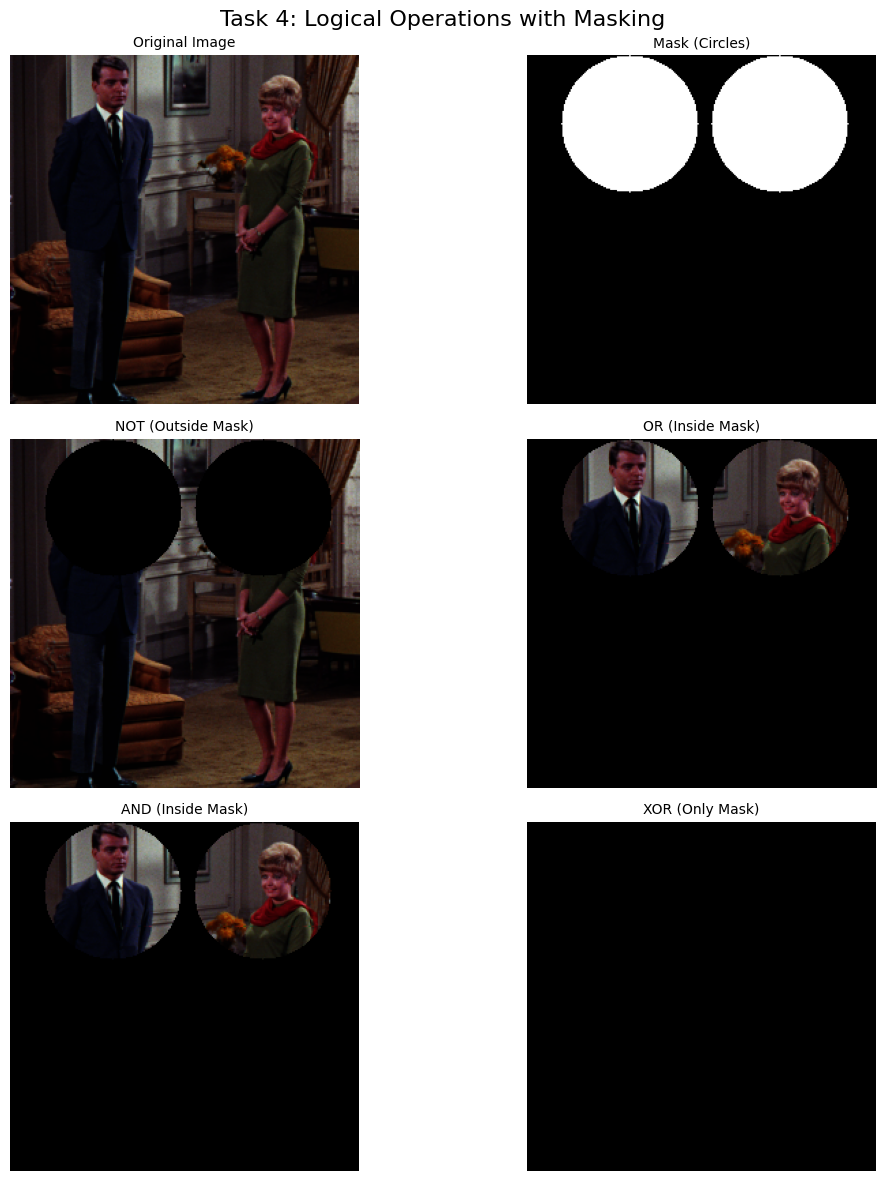

Task 4 completed and displayed in a 3x2 grid.


In [73]:
def task4_logical_masking_grid_3x2():
    print("=== TASK 4: LOGICAL OPERATIONS WITH MASKING (3x2 Layout) ===")

    # Load the input image
    img = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
    if img is None:
        print("Image not found. Please check the path.")
        return

    # Create a binary mask with two white circles
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv.circle(mask, (75, 50), 50, 255, -1)     # Left circle
    cv.circle(mask, (185, 50), 50, 255, -1)    # Right circle

    # Perform logical operations using the mask

    # NOT: invert the mask and apply it to the image
    not_mask = cv.bitwise_not(mask)
    not_result = cv.bitwise_and(img, img, mask=not_mask)

    # OR: show only the area inside the mask
    or_result = cv.bitwise_or(img, img, mask=mask)

    # AND: same as OR in this case (img & img = img), masked area only
    and_result = cv.bitwise_and(img, img, mask=mask)

    # XOR: show only the masked (non-overlapping) area
    xor_result = cv.bitwise_xor(img, img, mask=mask)

    # Convert the mask to 3-channel for consistent display
    mask_3ch = cv.merge([mask, mask, mask])

    # List of images and their respective titles
    images = [img, mask_3ch, not_result, or_result, and_result, xor_result]
    titles = [
        "Original Image",
        "Mask (Circles)",
        "NOT (Outside Mask)",
        "OR (Inside Mask)",
        "AND (Inside Mask)",
        "XOR (Only Mask)"
    ]

    # Display results in 3 rows × 2 columns
    plt.figure(figsize=(12, 12))
    for i in range(6):
        plt.subplot(3, 2, i + 1)
        img_rgb = cv.cvtColor(images[i], cv.COLOR_BGR2RGB)  # Convert BGR to RGB for display
        plt.imshow(img_rgb)
        plt.title(titles[i], fontsize=10)
        plt.axis("off")

    # Add a main title and show the full grid
    plt.suptitle("Task 4: Logical Operations with Masking", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("Task 4 completed and displayed in a 3x2 grid.")

# Run the task
task4_logical_masking_grid_3x2()
